### CNN2: transfer learning & fine-tuning


In [14]:
""" Anaconda: environment """

"""
conda create -n tf-gpu python==3.10
conda activate tf-gpu

pip install tensorflow==2.14.0 opencv-python pandas matplotlib scikit-learn
pip install numpy==1.26.4

"""

'\nconda create -n tf-gpu python==3.10\nconda activate tf-gpu\n\npip install tensorflow==2.14.0 opencv-python pandas matplotlib scikit-learn\npip install numpy==1.26.4\n\n'

In [1]:
################################################################################################
#########################      import                                   ########################
################################################################################################

import tensorflow as tf             # framework - creating and training AI models (last time we used PyTorch)
import numpy as np                  # operate on tables and matrices 
import os                           # work with files 
import cv2                          # image processing
import matplotlib.pyplot as plt     # visualization

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import CSVLogger


C:\Users\student\.conda\envs\tf-gpu\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


1. Decide whether you want to train the network "live" or use previously prepared logs (previously trained models).

    ``if_train = False`` : logs of previously trained models (faster version) 

    ``if_train = True`` : live training (more realistic, though probably slower version) 

In [2]:
#############################################################################################################
### if_train = False -> logs of previously trained models (faster version)       ############################
### if_train = True -> live training (more realistic, though probably slower version)                   #####
#############################################################################################################

if_train = False

2. Setting hyperparameters (only for launch).

In [3]:

################################################################################################
#########################      hyperparameters                           ########################
################################################################################################

IMG_SIZE = 128      # input image size (IMG_SIZE x IMG_SIZE)
BATCH_SIZE = 16     # mini-batch size
EPOCHS = 20         # max number of epochs (bo będziemy stosować mechanizm wczesnego zatrzymania)

IMAGE_PATH = "./db2/image"      # path to images
MASK_PATH = "./db2/mask"        # path to masks

# list of images and masks 
images = sorted([os.path.join(IMAGE_PATH, x) for x in os.listdir(IMAGE_PATH)])
masks  = sorted([os.path.join(MASK_PATH, x) for x in os.listdir(MASK_PATH)])

3. Split the HAM1000 database into subsets (using the ``train_test_split`` function of the ``scikit-learn`` library). Separate 15% of the validation set and 15% of the test set.

    ``TODO: fill the gaps in code!``

In [4]:
################################################################################################
#########################      division into subsets (FILL THE GAPS!)     ######################
################################################################################################
# use the train_test_split function (scikit-learn library);
# split 15% of the validation set and 15% of the test set

import pandas as pd
from src.utils import TVT_split
from sklearn.model_selection import train_test_split # hint if needed: https://datascience.stackexchange.com/posts/15135/revisions 

train_img, test_img, train_mask, test_mask = train_test_split(
        images, masks, test_size= 0.15, random_state=42
    )

train_img, val_img, train_mask, val_mask = train_test_split(
        train_img, train_mask, test_size=0.176, random_state=42
    )

print(f"Train: {len(train_img)} images, Val: {len(val_img)} images, Test: {len(test_img)} images")


################################################################################################
#########################       auxiliary (DO NOT REMOVE OR CHANGE!)      ######################
################################################################################################
train_img, val_img, test_img, train_mask, val_mask, test_mask = TVT_split(img_dim=IMG_SIZE)

Train: 7013 images, Val: 1499 images, Test: 1503 images
                             image                         mask
0     ./db2/image\ISIC_0025923.jpg  ./db2/mask\ISIC_0025923.png
1     ./db2/image\ISIC_0032434.jpg  ./db2/mask\ISIC_0032434.png
2     ./db2/image\ISIC_0026474.jpg  ./db2/mask\ISIC_0026474.png
3     ./db2/image\ISIC_0025396.jpg  ./db2/mask\ISIC_0025396.png
4     ./db2/image\ISIC_0032060.jpg  ./db2/mask\ISIC_0032060.png
...                            ...                          ...
1498  ./db2/image\ISIC_0030429.jpg  ./db2/mask\ISIC_0030429.png
1499  ./db2/image\ISIC_0025922.jpg  ./db2/mask\ISIC_0025922.png
1500  ./db2/image\ISIC_0028189.jpg  ./db2/mask\ISIC_0028189.png
1501  ./db2/image\ISIC_0024860.jpg  ./db2/mask\ISIC_0024860.png
1502  ./db2/image\ISIC_0032299.jpg  ./db2/mask\ISIC_0032299.png

[1503 rows x 2 columns]


4. Preparing the decoder (U-Net). Implement subsequent layers (description in the code).

<img src="./VGG16_UNet_blocks.png">

In [5]:
################################################################################################
#########################       BUILD THE DECODER                ###############################
##############        Complete the decoder convolution blocks            #######################  
############## and a single decoder block (uses a convolutional block)      ####################
################################################################################################


# Here you'll find the convolution and transposed convolution layers: https://keras.io/api/layers/convolution_layers/
# Here you'll find the normalization layers: https://keras.io/api/layers/normalization_layers/
# Here you'll find the activation layer: https://keras.io/api/layers/core_layers/activation/#activation-class
# Here you'll find the skip-connection layer: https://keras.io/api/layers/merging_layers/concatenate/

        # Example of building layers:
        # l = Conv2D(filters, 3, padding="same")(input)
        # l = BatchNormalization()(l)
        # l = Activation("relu")(l)

def conv_block(input, filters):

    # how to call a single layer: x = layer(parameters)(input)
    # number of filters == filters given as a parameter in the conv_block function (the function that you're inside)

    x = Conv2D(filters, 3, padding="same")(input) # 2D convolutional layer -> parameters: number of filters, kernel size, padding (set to "same"); input: input
    x = BatchNormalization()(x) # batch normalization layer -> input: previous layer
    x =  Activation("relu")(x)# activation layer (relu); use activation layer, not ReLU -> input: previous layer

    x = Conv2D(filters, 3, padding="same")(x)# 2D convolutional layer -> parameters: number of filters, kernel size, padding (set to "same"); input: previous layer
    x = BatchNormalization()(x)# batch normalization layer -> input: previous layer
    x = Activation("relu")(x) # activation layer (relu); use activation layer, not ReLU -> input: previous layer

    return x

def decoder_block(input, skip, filters):

    x = Conv2DTranspose(filters, (2, 2),strides =2, padding="same")(input)  # 2D transposed convolution layer -> parameters: number of filters, kernel size (2,2), stride (stride) = 2, padding (set to "same"); input: input
    x = Concatenate()([x, skip]) # skip-connection -> parameters: none; input: [(previous layer, skip parameter)]
    x = conv_block(x, filters) # convolutional block defined in the function above -> parameters: previous layer, number of filters;

    return x

4. Transfer learning: Download the encoder (VGG16) and connect to the decoder (U-Net). Freeze the relevant layers (complete the code!).

    `` TODO: freezing/unfreezing layers --> layer.trainable = _____ # False or True; whether to train layers or not ``

In [6]:
################################################################################################
#########################       Model construction: VGG16-UNet  ################################
#########################          TRANSFER LEARNING            ################################
################################################################################################

# COMPLETE FREEZING/UNFREEZING LAYERS

def build_model():

    # input layer specification
    inputs = Input((IMG_SIZE, IMG_SIZE, 3))

    # VGG16 architecture:
    # include_top -> whether to include the "head" of the classification;
    # weights -> network weights (DB name on which the network was trained or "none" if empty weights)
    vgg = VGG16(include_top=False, weights="imagenet", input_tensor=inputs)

    #COMPLETE HERE: Freezing/Unfreezing VGG16 Layers
    for layer in vgg.layers: # for all VGG16 layers (encoder)
        layer.trainable = False #False or True; whether to train layers or not

    # VGG16 ENCODER - UNet DECODER CONNECTION

    # encoder blocks 
    s1 = vgg.get_layer("block1_conv2").output
    s2 = vgg.get_layer("block2_conv2").output
    s3 = vgg.get_layer("block3_conv3").output
    s4 = vgg.get_layer("block4_conv3").output

    # bottleneck
    bridge = vgg.get_layer("block5_conv3").output

    # decoder blocks (+ skip-connections to encoder) 
    d1 = decoder_block(bridge, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = Conv2D(1, 1, activation="sigmoid")(d4)

    model = Model(inputs, outputs)

    return model

5. Define the loss function (combination of binary cross entropy and Dice). Define the quality metrics (Dice coefficient, Jaccard index). Just run the code.

In [7]:
################################################################################################
#########################     Metrics: training and loss function   ############################
################################################################################################

# DICE SIMILARITY COEFFICIENT
def dice_coeff(y_true, y_pred, smooth=1e-6):
    
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # flatten per sample
    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true * y_pred, axis=1)
    denominator = tf.reduce_sum(y_true + y_pred, axis=1)

    dice = (2. * intersection + smooth) / (denominator + smooth)

    return tf.reduce_mean(dice)

# INTERSECTION OVER UNION (IoU, also known as Jaccard Index)
def iou(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # flatten per sample: [B, H*W*(C)]
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union        = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return tf.reduce_mean(iou)

# LOSS FUNCTION: DICE INDEX
def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

#HYBRID LOSS FUNCTION: COMBINATION OF BINARY CROSS ENTROPY AND DICE
def bce_dice_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    d = dice_loss(y_true, y_pred)

    return bce + d

6. Training process control mechanisms. Add: early stopping, model saving during training, learning rate (LR) reduction during training.

        `` TODO: COMPLETE GAPS IN CODE ``

In [8]:
################################################################################################
#########################    Mechanisms for controlling the training process   #################
################################################################################################

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


# EARLY STOP (stops training if there is no improvement in the validation loss value for the specified number of epochs)
#       ---> set patience to 5 epochs

early_stop = EarlyStopping(
    monitor= "val_loss",
    patience= 5,
    restore_best_weights=True
)

# SAVING THE MODEL DURING TRAINING
#       ---> set validation loss monitoring ("val_loss")

ckpt = ModelCheckpoint(
    "transfer_learning_model.h5", 
    monitor= 'val_loss',
    save_best_only=True, 
    save_weights_only=False
)

# REDUCE LEARNING RATE DURING TRAINING IF THERE'S NO IMPROVEMENT IN VAL LOSS
#       ---> set the learning rate to 0.5 and the patience to 2 epochs 

plateauLR = ReduceLROnPlateau(monitor="val_loss",
                              factor=0.5,
                              patience=2,
                              min_lr=1e-6, 
                              verbose=1)


7. Compile the model and display the number of parameters. Just run.

In [9]:
################################################################################################
#########################       Model compilation and summary                 ##################
################################################################################################

model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=bce_dice_loss,
    metrics=["accuracy", 
             dice_coeff, 
             iou]
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 128, 128, 64)         1792      ['input_1[0][0]']             
                                                                                                  
 block1_conv2 (Conv2D)       (None, 128, 128, 64)         36928     ['block1_conv1[0][0]']        
                                                                                                  
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)           0         ['block1_conv2[0][0]']        
                                                                                              

8. Transfer Learning: Training (run only).

In [10]:
################################################################################################
#########################       TRANSFER LEARNING: training                   ##################
################################################################################################

# all VGG16 layers are frozen, only the decoder will be trained

from src.utils import load_logs_tf

train_mask = train_mask[:,:,:,0:1]
val_mask = val_mask[:,:,:,0:1]

from src.utils import FullCSVLogger

if if_train:

    history = model.fit(
        train_img,
        train_mask,
        validation_data=(val_img, val_mask),
        epochs=EPOCHS,
        callbacks=[ckpt, early_stop, plateauLR]
    )

else:
    model = load_logs_tf()


Epoch 0: 94/94 [====================>] ETA: 0.0 s 0.02s/step loss: 0.5761 acc: 0.8982 dice: 0.6800 iou: 0.5505.6798 iou: 0.5503
Epoch 1: 94/94 [====================>] ETA: 0.0 s 0.02s/step loss: 0.3409 acc: 0.9449 dice: 0.8095 iou: 0.6993.8087 iou: 0.6983
Epoch 2: 94/94 [====================>] ETA: 0.0 s 0.02s/step loss: 0.2929 acc: 0.9511 dice: 0.8383 iou: 0.73788381 iou: 0.7376
Epoch 3: 94/94 [====================>] ETA: 0.0 s 0.02s/step loss: 0.2694 acc: 0.9534 dice: 0.8539 iou: 0.7603537 iou: 0.760002
Epoch 4: 94/94 [====================>] ETA: 0.0 s 0.02s/step loss: 0.2444 acc: 0.9568 dice: 0.8693 iou: 0.78208694 iou: 0.7822
Epoch 5: 94/94 [====================>] ETA: 0.0 s 0.02s/step loss: 0.2338 acc: 0.9577 dice: 0.8769 iou: 0.7934.8771 iou: 0.7937
Epoch 6: 94/94 [====================>] ETA: 0.0 s 0.02s/step loss: 0.2129 acc: 0.9611 dice: 0.8893 iou: 0.8111.8893 iou: 0.8111
Epoch 7: 94/94 [====================>] ETA: 0.0 s 0.02s/step loss: 0.1994 acc: 0.9629 dice: 0.8969 iou: 0.

9. Transfer learning: validate the finished model (just run). SAVE THE RESULTS IN A TABLE IN THE REPORT.

22/22 [==============================] - 16s 715ms/step - loss: 0.2387 - accuracy: 0.9540 - dice_coeff: 0.8983 - iou: 0.8297
=============== QUALITY METRICS 
Accuracu: 0.9540252685546875
Dice Index: 0.898254930973053
IoU: 0.8296515941619873
  
  
=============== SOME RESULTS 
1/1 [==============================] - 0s 211ms/step


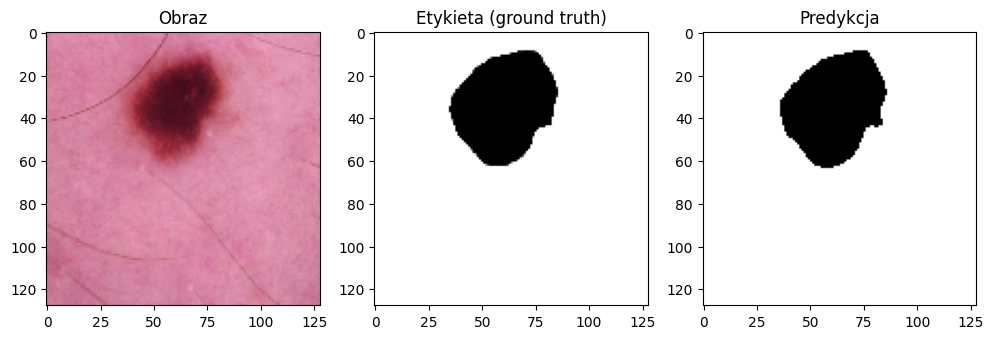

1/1 [==============================] - 0s 80ms/step


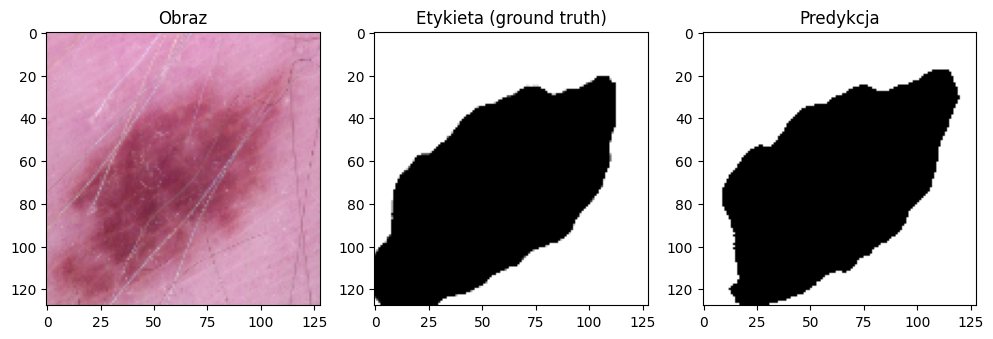

1/1 [==============================] - 0s 80ms/step


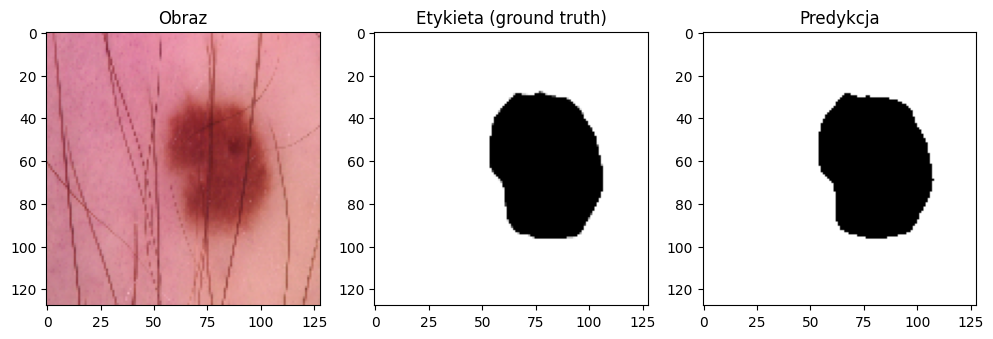

1/1 [==============================] - 0s 79ms/step


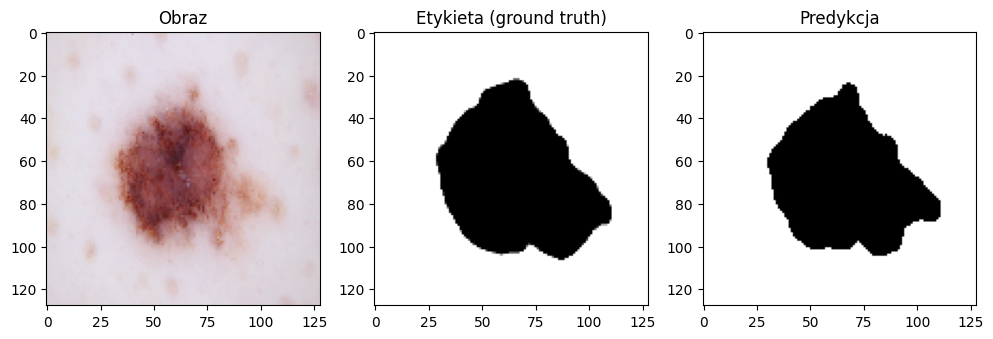

1/1 [==============================] - 0s 79ms/step


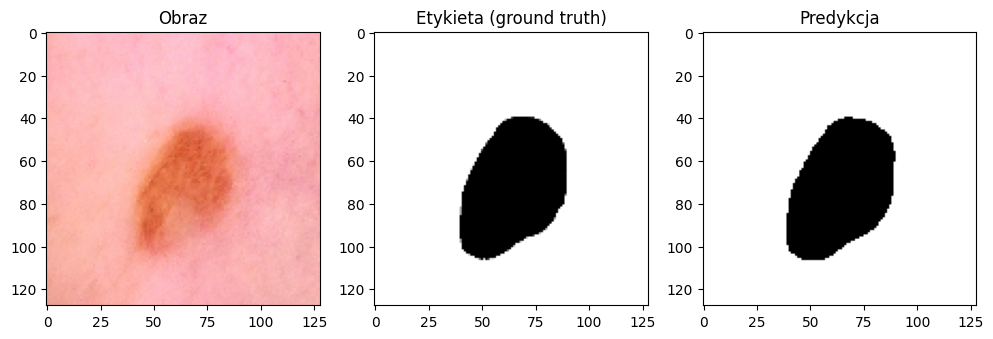

In [11]:
################################################################################################
#########################       TRANSFER LEARNING: Validating Results         ##################
################################################################################################

test_loss, test_acc, dsc, iou_m = model.evaluate(test_img, test_mask[..., 0], verbose=1)

print("=============== QUALITY METRICS ")
print("Accuracu:", test_acc)
print("Dice Index:", dsc)
print("IoU:", iou_m)

from src.utils import show_prediction
print("  ")
print("  ")
print("=============== SOME RESULTS ")
for i in range(5):
    show_prediction(model, test_img[i], test_mask[i])

10. Fine-tuning the network.

Refer to Figure 4 (the last one) in the instructions. Make sure you can distinguish between the encoder and decoder, as well as the individual encoder blocks (five blocks).

Set:

(1) ``ft_from_block`` - from which encoder block to unfreeze layers (1-5, where in case 1 everything is unfreezed and the entire encoder-decoder network is trained, and in case 5 the last encoder block is unfreezed).

(2) ``lr`` - learning rate (use one of the values: 1e-4, 1e-5, 1e-6).

SAVE THE RESULTS IN THE TABLE IN THE REPORT.

In [ ]:
################################################################################################
#########################       FINE-TUNING: Training                         ##################
################################################################################################

# the decoder and some layers from the encoder (VGG16) will be trained

import os
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from src.utils import fine_tuning_settings, FullCSVLogger
from src.utils import load_logs_ft

# wczytanie wyniku uczenia transferowego
model_ft = tf.keras.models.load_model(
    "./src/models/transfer_learning_model.h5",
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coeff": dice_coeff,
        "iou": iou
    })


################################################################################################
#########################       FINE-TUNING: unfreeze encoder layers          ##################
################################################################################################

# ft_from_block = from which encoder block (VGG16) to unfreeze layers
# e.g. 1 -> everything is unfreezed, the entire encoder-decoder network is trained; 5 -> only the last encoder layers are unfreezed
ft_from_block = 5 # 1, 2, 3, 4, 5

# lr = learning rate
# use one of the values: 1e-4, 1e-5, 1e-6
lr = 1e-5 # 1e-4,  1e-5, 1e-6

lr_label = f"{lr:.0e}".split("e-")[1]
exp_name = f"block{ft_from_block}_lr{lr_label}"

print(f"\n====== FINE-TUNING: {exp_name} ======\n")

# UNFREEZING 
for layer in model_ft.layers:
    if "block" in layer.name:
        block_number = int(layer.name[5])

        if block_number >= ft_from_block:
            layer.trainable = True
        else:
            layer.trainable = False
          
# CALLBACKS (training monitoring mechanisms)
ckpt2 = ModelCheckpoint(
    f"./models/fine_tuning_{exp_name}.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
    )

early2 = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

plateau2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)
if_train = False
if if_train:
    # COMPILE THE MODEL
    model_ft.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=bce_dice_loss,
        metrics=["accuracy", dice_coeff, iou]
    )

    # TRAIN IT
    history_fine_tuning = model_ft.fit(
        train_img,
        train_mask,
        validation_data=(val_img, val_mask),
        epochs=20,
        batch_size=16,
        callbacks=[ckpt2, early2, plateau2, FullCSVLogger(f"./logs/training_log_{exp_name}.csv")],
        verbose=1
    )   

else:
    model_ft = load_logs_ft(exp_name)

train_y = train_mask[:,:,:,0:1]
val_y = val_mask[:,:,:,0:1]
test_y = test_mask[:,:,:,0:1]

################################################################################################
#########################       FINE-TUNING: validation                       ##################
################################################################################################

test_loss, test_acc, dsc, iou_m = model_ft.evaluate(test_img, test_mask[..., 0], verbose=1)
print("  ")
print("  ")
print("=============== QUALITY METRICS ")
print("Accuracu", test_acc)
print("Dice Index:", dsc)
print("IoU:", iou_m)

from src.utils import show_prediction
print("  ")
print("  ")
print("=============== SOME RESULTS ")
for i in range(5):
    show_prediction(model, test_img[i], test_mask[i])